# Population vs Sample
Suppose these are the daily revenues of a population of 20 hotel-days:
revenues = np.array([
    18000, 19500, 21000, 22500, 17000,
    24000, 20500, 19000, 21500, 23000,
    18500, 20000, 25000, 17500, 22000,
    19500, 23500, 20500, 18000, 21000
])
For this exercise, pretend these 20 observations represent our entire population.

### Part A — Population statistics

Calculate:

1. Population size N
2. Population mean μ
3. Population standard deviation σ

### Part B — Take one sample

Set a random seed:

np.random.seed(42)

Then randomly select 5 observations from the population without replacement.

Calculate the sample's:

1. size n
2. mean
3. xˉ
4. sample standard deviation s
   
### Part C — Compare

Print:

Population mean: ...
Sample mean: ...

Population std: ...
Sample std: ...

Then calculate:

 xˉ−μ

and explain what that number tells you.

### Part D — Reasoning

Answer these conceptually:

1. Why isn't the sample mean necessarily equal to the population mean?
2. If you take another random sample of 5 observations, do you expect exactly the same sample mean?
3. If you took many different samples of 5 observations, what do you think would happen to their means?
4. Which sample would you generally expect to give a more reliable estimate of the population mean:

n=3
n=15

Explain why, not just which one.

Important

Don't calculate standard error yet.

I specifically want you to first see the problem that standard error will eventually describe:

different random samples⇒different sample means

This phenomenon is called sampling variability.

In [1]:
import numpy as np 

revenues = np.array([
    18000, 19500, 21000, 22500, 17000,
    24000, 20500, 19000, 21500, 23000,
    18500, 20000, 25000, 17500, 22000,
    19500, 23500, 20500, 18000, 21000
])

size = len(revenues)
population_mean = np.mean(revenues)
population_std_dev = np.std(revenues,ddof=0)

print(f"Population'size is {size}")
print(f"Population'mean is {population_mean}")
print(f"Population'standard deviation is {population_std_dev}")

np.random.seed(42)
sample = np.random.choice(revenues,5, replace=False)

sample_size = len(sample)
sample_mean = np.mean(sample)
sample_standard_deviation = np.std(sample, ddof=1)
print()
print(f"Sample'size is {sample_size}")
print(f"Sample'mean is {sample_mean}")
print(f"Sample'standard deviation is {sample_standard_deviation}")
print(f"xˉ−μ = {sample_mean - population_mean}, it tells us how far particular sample mean is from the true population mean." )
print()
print("Sample mean is not necessarily equal to the population mean because we use random sampling to calculate.")
print("No, I don't expect exactly same sample mean.The difference is one manifistation of sampling variability.")
print("If I took many different sample of 5 different observations, theirs mean will be distributed around population mean.")
print("Sample size = 15 will give more reliable estimate of population mean becase a larger sample is less affected by which particular observations happened to be selected.")


Population'size is 20
Population'mean is 20575.0
Population'standard deviation is 2209.4965489902897

Sample'size is 5
Sample'mean is 19800.0
Sample'standard deviation is 1303.8404810405298
xˉ−μ = -775.0, it tells us how far particular sample mean is from the true population mean.

Sample mean is not necessarily equal to the population mean because we use random sampling to calculate.
No, I don't expect exactly same sample mean.The difference is one manifistation of sampling variability.
If I took many different sample of 5 different observations, theirs mean will be distributed around population mean.
Sample size = 15 will give more reliable estimate of population mean becase a larger sample is less affected by which particular observations happened to be selected.


---

# Task 2: Sampling Distribution of the Mean
Use the same revenues population.

###  Part A — Take 1,000 samples
np.random.seed(42)

sample_means = []

Then use a loop to:

1. Take 1,000 different random samples.
2. Each sample should contain n=5 observations.
3. Sample without replacement.
4. Calculate each sample's mean.
5. Append that mean to sample_means.

Conceptually:

Population
    ↓
sample 1 (n=5) → mean₁
sample 2 (n=5) → mean₂
sample 3 (n=5) → mean₃
...
sample 1000     → mean₁₀₀₀

Don't worry that observations can appear again in a different sample. replace=False only means an observation cannot be selected twice within the same sample.

### Part B — Inspect the sample means

Convert sample_means to a NumPy array.

Calculate:

6. minimum sample mean
7. maximum sample mean
8. mean of all 1,000 sample means
9. standard deviation of the 1,000 sample means

Also print the original population mean.

Compare:

mean of sample means

with:

μ

Don't use a standard-error formula yet.

### Part C — Visualize the sampling distribution

Create a histogram of your 1,000 sample means.

Try around: bins=30

Add a vertical line for the population mean.

Your x-axis is important here. It does not represent individual revenues anymore.

It represents: sample means

### Part D — Compare two distributions

Create a second, separate histogram showing the original 20 individual revenues.

Compare it with the histogram of the 1,000 sample means.

Answer:

1. Which distribution has the larger spread: individual revenues or sample means?
2. Are the sample means centered approximately around the population mean?
3. Why do you think sample means vary less than individual observations?
4. What does the standard deviation of your 1,000 sample means seem to measure?

For question 4, don't search for the formal term yet. Describe what you think it means in your own words.

Main idea

You now have a new distribution:

distribution of sample means

This is called a sampling distribution of the sample mean.

Be careful with the terminology:

Population distribution
→ distribution of individual revenues

Sample
→ 5 randomly selected revenues

Sampling distribution
→ distribution of the means from many samples

Min sample mean is 18100.0
Max sample mean is 23200.0
The mean of sample means is 20565.7
Std deviation of sample means is 908.7868341916052
The population mean is 20575.0
The distance from mean of samples mean to population mean is -9.299999999999272


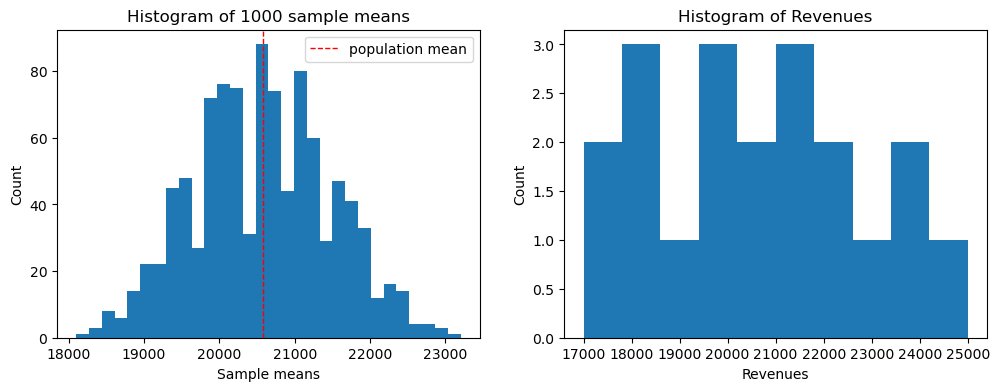


Individual revenues's distribution has larger spread.
Sample means are centered approximately around population mean.
Because each sample mean combines information from several observations. High and low values tend to partially balance each other.
Standard deviation on 1000 sample mean  measures how much sample means vary around the population mean from sample to sample.


In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
revenues = np.array([
    18000, 19500, 21000, 22500, 17000,
    24000, 20500, 19000, 21500, 23000,
    18500, 20000, 25000, 17500, 22000,
    19500, 23500, 20500, 18000, 21000
])

sample_means = []

np.random.seed(42)

for i in range(1000):
    sample = np.random.choice(revenues,5, replace=False)
    sample_means.append(np.mean(sample))

sample_means = np.array(sample_means)
min_sample_mean = sample_means.min()
max_sample_mean = sample_means.max()
samples_mean = np.mean(sample_means)
std_dev_samples = np.std(sample_means, ddof=0)
population_mean = np.mean(revenues)

print(f"Min sample mean is {min_sample_mean}")
print(f"Max sample mean is {max_sample_mean}")
print(f"The mean of sample means is {samples_mean}")
print(f'Std deviation of sample means is {std_dev_samples}')
print(f"The population mean is {population_mean}")

print(f"The distance from mean of samples mean to population mean is {samples_mean-population_mean}")

figure,ax  = plt.subplots(1, 2,figsize=(12,4))
ax[0].hist(sample_means,bins=30)
ax[0].axvline(population_mean, color='r',linewidth=1, linestyle='--', label='population mean')
ax[0].set_xlabel("Sample means")
ax[0].set_ylabel("Count")
ax[0].set_title("Histogram of 1000 sample means")
ax[0].legend()

ax[1].hist(revenues)
ax[1].set_title('Histogram of Revenues')
ax[1].set_xlabel('Revenues')
ax[1].set_ylabel('Count')
plt.show()

print()
print("Individual revenues's distribution has larger spread.")
print("Sample means are centered approximately around population mean.")
print("Because each sample mean combines information from several observations. High and low values tend to partially balance each other.")
print("Standard deviation on 1000 sample mean  measures how much sample means vary around the population mean from sample to sample.")

---

# Task 3: Standard Error & Sample Size

The standard deviation of the sampling distribution of the mean is called the standard error of the mean (SE):

SE=σ / sqrt(n)
where:

σ = population standard deviation
n = sample size
SE = standard deviation of the sampling distribution of sample means

### Part A — Theoretical standard error
Using the same revenues population, calculate:

population_std = ...

Then calculate the theoretical standard error for n=5 using the formula above.

You already have the empirical standard deviation of your 1,000 sample means from Task 2: std_dev_samples

Compare:

Theoretical SE: ... 

Observed std of sample means: ...

Are they approximately equal?

### Part B — Change the sample size
Now repeat the simulation separately for these sample sizes:

n=2,n=5,n=10,n=15

For each n:

1. Generate 1,000 random samples.
2. Use replace=False.
3. Calculate each sample mean.
4. Calculate the standard deviation of those 1,000 means.
5. Calculate the theoretical:
6. SE= population_std_Dev / sqrt(n)

Store your results somehow so you can compare them.

You should end up with something conceptually like:
| Sample size | Observed std of sample means | Theoretical SE |
| ----------: | ---------------------------: | -------------: |
|           2 |                            ? |              ? |
|           5 |                            ? |              ? |
|          10 |                            ? |              ? |
|          15 |                            ? |              ? |


### Part C — Visualization

Create four separate histograms, one for each sampling distribution.

Use the same x-axis limits for all four so the difference in spread is visually meaningful.

Add a vertical line at the population mean to each graph.

Compare how the shape changes as:

n:2→5→10→15

### Part D — Reasoning

Answer these:

1. What happens to the standard error when n increases?
2. What happens to the sampling distribution visually when n increases?
3. Why does a larger sample give a more stable estimate of μ?
4. If we increase the sample size from n=25 to n=100, does the standard error become:

- half as large,
- one quarter as large,
- or something else?

5. If you wanted to cut the standard error in half, by what factor would you need to increase n?

### One important complication

Our population contains only 20 observations, and you're sampling without replacement.

The simple formula

SE= population_std_Dev / sqrt(n)


assumes an effectively very large population or sampling with replacement.

Because n=15 is a large fraction of our N=20, your simulated standard deviation may become noticeably smaller than this simple theoretical SE.

Don't fix this yet.

If you observe that discrepancy, point it out. We'll use it to understand something important about sampling without replacement.

The main goal of Task 3 is to discover experimentally:

larger n⇒smaller variability of 
X
ˉ



and understand why the square root in SE= population_std_Dev / sqrt(n) matters.

In [3]:
revenues = np.array([
    18000, 19500, 21000, 22500, 17000,
    24000, 20500, 19000, 21500, 23000,
    18500, 20000, 25000, 17500, 22000,
    19500, 23500, 20500, 18000, 21000
])
population_std_dev = np.std(revenues)
theoretical_standard_error = population_std_dev / np.sqrt(5)

print(f"Theoretical Standard Error : {theoretical_standard_error}")
print(f'Observed std of sample means: {std_dev_samples}')
print(f"They are approximately equal.")

theoretical_standard_errors = []
n = [2, 5, 10, 15]

result = {}
sample_means_by_size = {}
for size in n:
    means = []
    for i in range(1000):
        sample = np.random.choice(revenues,size,replace=False)
        mean = np.mean(sample)
        means.append(mean)
    std_dev_means = np.std(np.array(means),ddof=0)       
    standard_error = population_std_dev / np.sqrt(size) 
    result[size] = [std_dev_means, standard_error]
    sample_means_by_size[size] = means 
    
print("Sample size\tObserved std of sample means\tTheoretical SE")
for size,values in result.items():
    print(size, f"Observed std: {values[0]}, Theoretical SE: {values[1]}")

Theoretical Standard Error : 988.1168959186964
Observed std of sample means: 908.7868341916052
They are approximately equal.
Sample size	Observed std of sample means	Theoretical SE
2 Observed std: 1545.0054813818622, Theoretical SE: 1562.3499927993087
5 Observed std: 880.9733196868109, Theoretical SE: 988.1168959186964
10 Observed std: 508.5541244548116, Theoretical SE: 698.7041577091122
15 Observed std: 287.8790621848773, Theoretical SE: 570.4895558494768


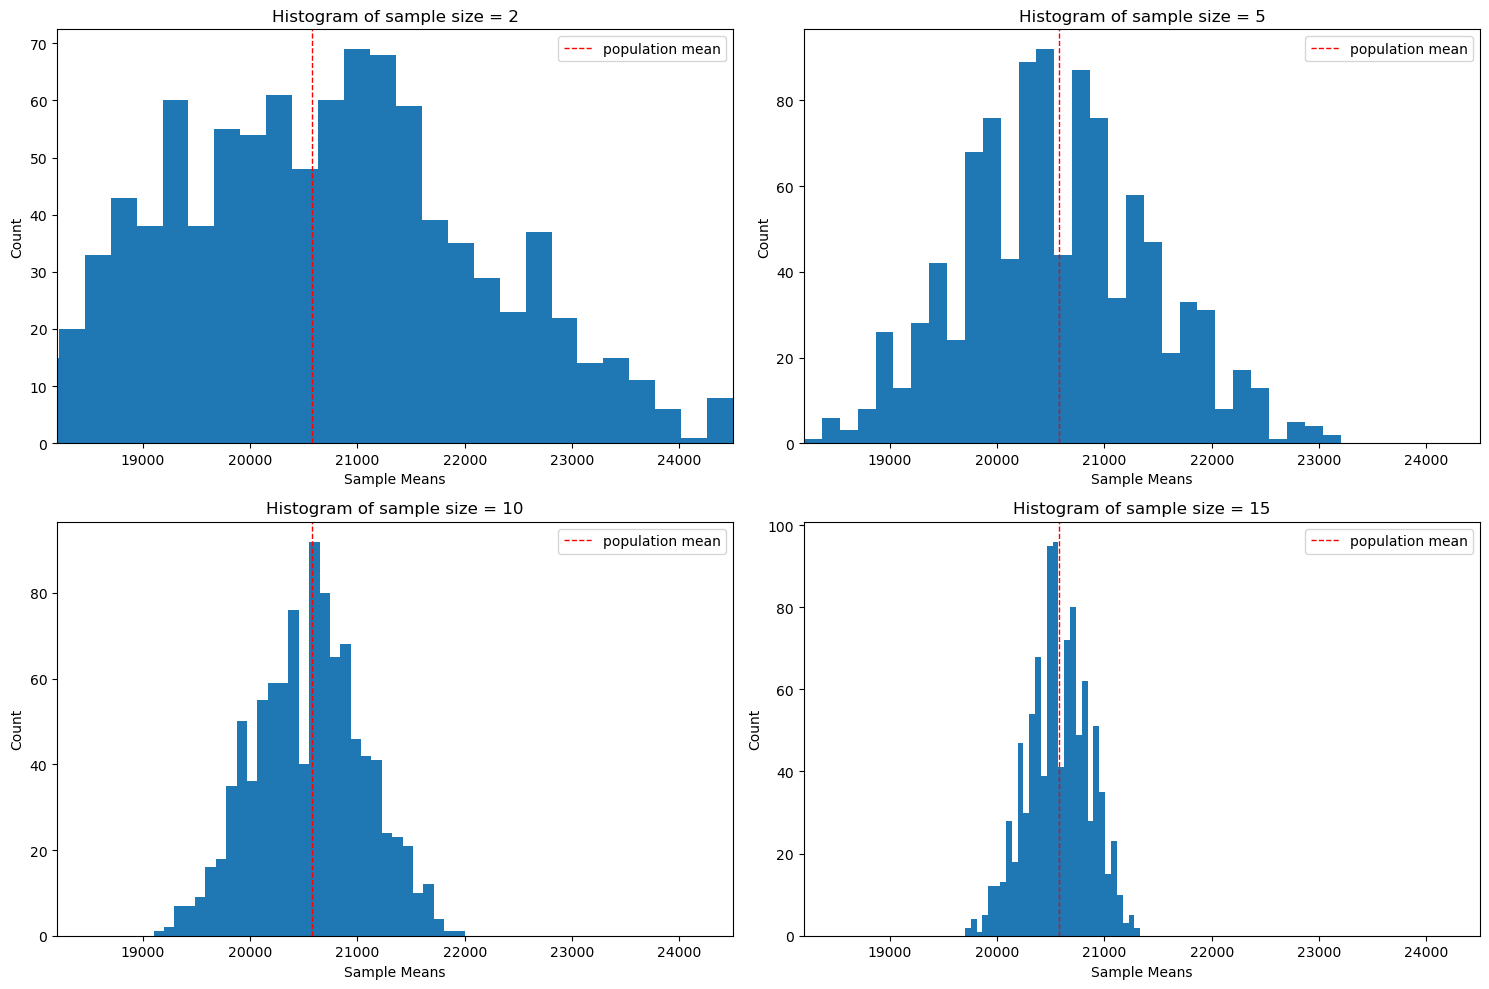

In [4]:
figure, ax = plt.subplots(2,2, figsize=(15,10))
x_min = min(min(arr for arr in sample_means_by_size.values()))
x_max = max(max(arr for arr in sample_means_by_size.values()))
ax = ax.flatten()
for i in range(len(sample_means_by_size)):
    ax[i].hist(sample_means_by_size[n[i]],bins=30)
    ax[i].set_xlim(x_min,x_max)
    ax[i].axvline(population_mean, color='r', linewidth=1, linestyle='--', label='population mean')
    ax[i].set_xlabel('Sample Means')
    ax[i].set_ylabel('Count')
    ax[i].set_title(f'Histogram of sample size = {n[i]}')
    ax[i].legend()
plt.tight_layout()
plt.show()

In [5]:
print("Standard error decreases with increase size of sample.")
print("The sampling distribution becomes narrower and more concentrated around the population mean.")
print("With more observations, individual unusual values have less influence on the sample mean, therefore sample mean fluctates less from sample to sample.")
print("SE decreased by half.")
print("As consequence of previous question, by factor 4.")

Standard error decreases with increase size of sample.
The sampling distribution becomes narrower and more concentrated around the population mean.
With more observations, individual unusual values have less influence on the sample mean, therefore sample mean fluctates less from sample to sample.
SE decreased by half.
As consequence of previous question, by factor 4.


---

# Task 4: Discovering the Central Limit Theorem
Now we'll investigate another important property:

What happens to the shape of the sampling distribution when the original population is not normally distributed?

### Part A — Create a strongly skewed population

Instead of our small revenue population, generate a large right-skewed population:
np.random.seed(42)

population = np.random.exponential(
    scale=2000,
    size=100_000
)

Do not worry about the exponential distribution formula yet. We are using it simply because it produces clearly right-skewed data.

Calculate:

1. population mean
2. population standard deviation

Then plot a histogram of the population.

Use enough bins to clearly see its shape, for example around 50.

Answer:

Does this population look normally distributed? Describe its shape.

### Part B — Sampling distributions

Now investigate four sample sizes:

n=2,n=5,n=30,n=100

For each sample size:

Take 5,000 random samples from population.
Calculate the mean of every sample.
Store all 5,000 sample means.

This time use: replace=True

Why? We're treating the generated array as representing a very large underlying population, and this also lets us compare directly with the standard SE formula without finite-population correction.

### Part C — Visualize

Create four histograms of the sampling distributions:
n=2          n=5

████         ███
█████       █████
██████     ███████
   ███


n=30         n=100

   ███         ███
 ███████     ███████
█████████   █████████

Use the same x-axis limits for all four plots.

Add the population mean as a vertical line.

Pay particular attention to the shape, not just the spread.

### Part D — Measure the distributions

For each sample size calculate:

1. Mean of the 5,000 sample means.
2. Standard deviation of the 5,000 sample means.
3. Theoretical standard error:
 SE = population_std_dev / sqrt(n)

| (n) | Mean of sample means | Observed SD | Theoretical SE |
| --: | -------------------: | ----------: | -------------: |
|   2 |                    ? |           ? |              ? |
|   5 |                    ? |           ? |              ? |
|  30 |                    ? |           ? |              ? |
| 100 |                    ? |           ? |              ? |

Look for two different patterns:

E(Xˉ)≈μ

and:

SD(Xˉ)≈population_std_dev / sqrt(n)

### Part E — Reasoning

Based only on your experiment, answer:

The original population is strongly right-skewed. What happens to the shape of the sampling distribution of the mean as n increases?
Does the sampling distribution become more or less skewed?
Where are the sampling distributions centered?
What happens to their spread as n increases?
At approximately which of our tested sample sizes does the histogram start looking reasonably normal to you?
Does this experiment suggest that the original population itself becomes normal when n increases? Explain carefully.
The key question

Don't look up the formal definition of the Central Limit Theorem yet.

After completing the experiment, write your own one- or two-sentence rule describing what you think is happening to the distribution of sample means as sample size increases.

Then we'll compare your rule with the actual Central Limit Theorem.

Population mean is 1991.9403181123698
Population standard deviation is 1985.9380946287924


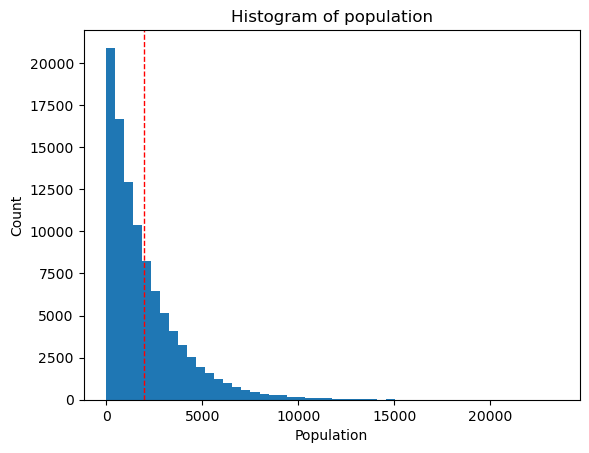

Distribution is NOT look like normal. It looks more like right skewed, because most observations are concentrated at relatively low values, while a smaller number of large values create long tail extending to the right. 


In [6]:
np.random.seed(42)

population = np.random.exponential(scale=2000,size=100_000)

population_mean = population.mean()
population_std_dev = population.std()
print(f"Population mean is {population_mean}")
print(f"Population standard deviation is {population_std_dev}")

plt.hist(population,bins=50)
plt.axvline(population_mean,color='r', linestyle='--', linewidth=1)
plt.xlabel("Population")
plt.ylabel("Count")
plt.title("Histogram of population")
plt.show()
print("Distribution is NOT look like normal. It looks more like right skewed, because most observations are concentrated at relatively low values, while a smaller number of large values create long tail extending to the right. ")

sample_sizes = [2,5,30,100]
samples_info = {}
for size in sample_sizes:
    samples = []
    samples_mean = []
    for i in range(5000):
        sample = np.random.choice(population, size, replace=True)
        samples.append(sample)
        mean = np.mean(sample)
        samples_mean.append(mean)
        
    samples_info[size]= [samples_mean, samples]

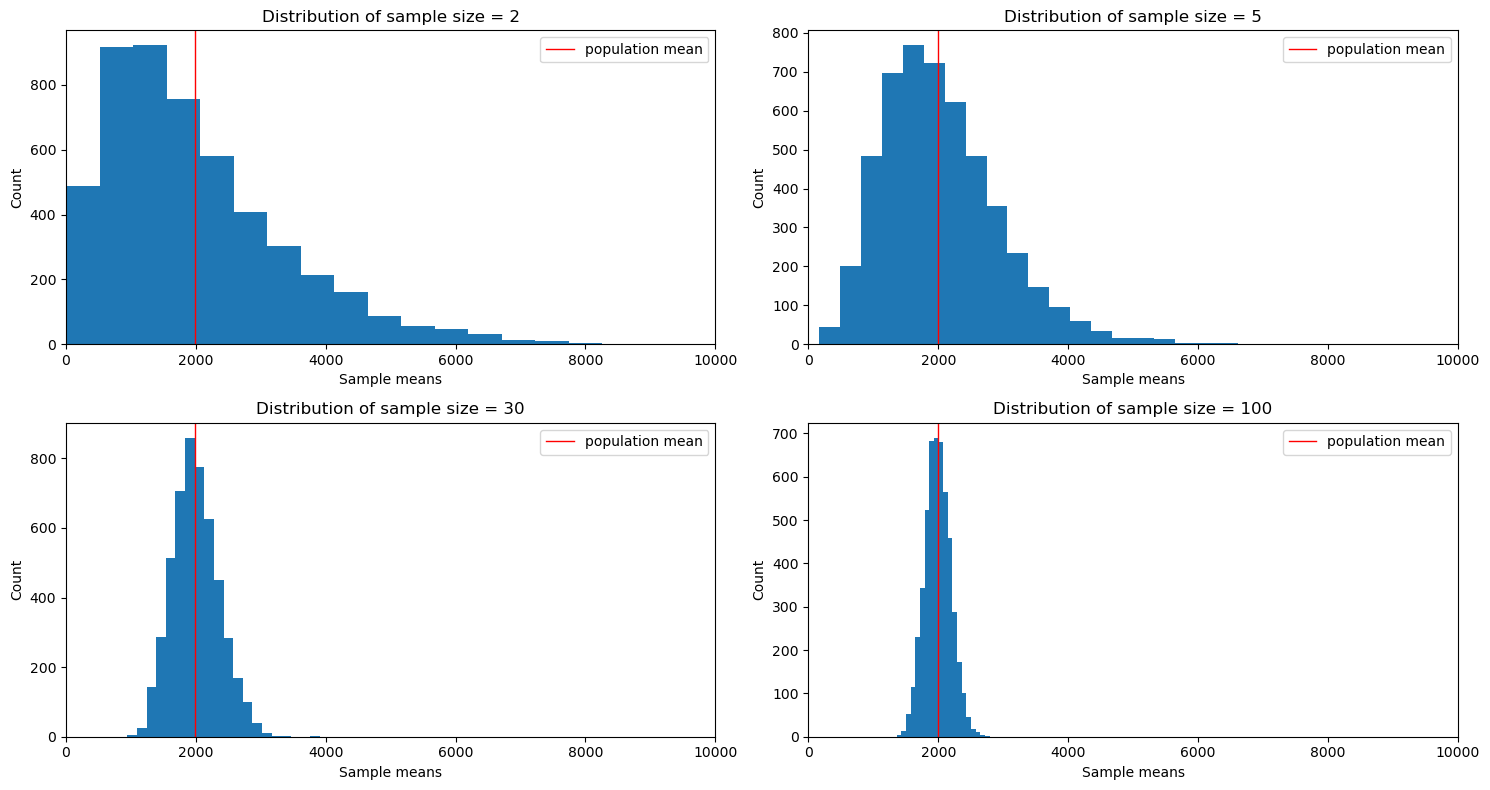

In [7]:
figure,ax = plt.subplots(2,2, figsize=(15,8))
ax=ax.flatten()
for i in range(len(sample_sizes)):
    ax[i].hist(samples_info[sample_sizes[i]][0],bins=20)
    ax[i].set_xlim(0,10000)
    ax[i].set_title(f'Distribution of sample size = {sample_sizes[i]}')
    ax[i].set_xlabel('Sample means')
    ax[i].set_ylabel('Count')
    ax[i].axvline(population_mean, color='r', linestyle='-', linewidth=1, label='population mean')
    ax[i].legend()
plt.tight_layout()
plt.show()

In [8]:
for size in sample_sizes:
    print(f"For size: {size} the mean of 5000 sample means is {np.mean(samples_info[size][0])}")
    print(f"Population mean is {population_mean}")
    print(f"For size: {size} std deviation of 5000 sample means is {np.std(samples_info[size][0])}")
    print(f"For size: {size} Standard Error is {population_std_dev/np.sqrt(size)}")
    print()

For size: 2 the mean of 5000 sample means is 1987.7715308565005
Population mean is 1991.9403181123698
For size: 2 std deviation of 5000 sample means is 1386.9141449236433
For size: 2 Standard Error is 1404.2702937287106

For size: 5 the mean of 5000 sample means is 2035.750688724704
Population mean is 1991.9403181123698
For size: 5 std deviation of 5000 sample means is 901.9665629741598
For size: 5 Standard Error is 888.138515739278

For size: 30 the mean of 5000 sample means is 2000.150779625286
Population mean is 1991.9403181123698
For size: 30 std deviation of 5000 sample means is 357.85916024884034
For size: 30 Standard Error is 362.58103074567293

For size: 100 the mean of 5000 sample means is 1990.4117694756162
Population mean is 1991.9403181123698
For size: 100 std deviation of 5000 sample means is 198.66120778318523
For size: 100 Standard Error is 198.59380946287925



In [9]:
print("As we increased the sample size, the sampling distribution of sample means become more approximately normal.")
print("With incraesing the sample size, distribution gets less right skewed and eventually transform itselft in normal.")
print("Around population mean.")
print("Their spread gets narrower with increasing n, because SE=population_std_dev / np.sqrt(n), with increase the n SE decreased")
print("On n = 30, histogram first look reasonably bell-shaped.")
print("Original exponential population does NOT become normal. With increasing the size of samples, their distribution of means become approximately normal.")
print("CLT - As size of sample increasing, the sampling distribution of sample means become more approximately normal, even when the original population it not normal.\
It is centered at the population mean, and its spread becomes smaller as n increases.")

As we increased the sample size, the sampling distribution of sample means become more approximately normal.
With incraesing the sample size, distribution gets less right skewed and eventually transform itselft in normal.
Around population mean.
Their spread gets narrower with increasing n, because SE=population_std_dev / np.sqrt(n), with increase the n SE decreased
On n = 30, histogram first look reasonably bell-shaped.
Original exponential population does NOT become normal. With increasing the size of samples, their distribution of means become approximately normal.
CLT - As size of sample increasing, the sampling distribution of sample means become more approximately normal, even when the original population it not normal.It is centered at the population mean, and its spread becomes smaller as n increases.


---

# Task 5: Confidence Intervals
You've established:

SE=population std / sqrt (sample size)

is approximately normally distributed around μ

Now we'll use those ideas for something practical:

We don't know the population mean. Can we use one random sample to estimate a reasonable range for it?

That range is a confidence interval.

### Part A — Create the population

For this experiment, we secretly know the population, so later we can check whether our confidence interval worked.

np.random.seed(42)

population = np.random.normal(
    loc=20_000,
    scale=3_000,
    size=100_000
)

Calculate:

1. population_mean
2. population_std
   
Then take one random sample of 100 observations and Calculate:

sample mean 

sample standard deviation s

For now, pretend you cannot see population_mean after calculating it. In a real problem, that's usually the unknown quantity we're trying to estimate.

Part B — Standard Error

Calculate the estimated Standard Error using your sample:
SE = s / sqrt(n)

s - sample std deviation.

What does this SE represent in this experiment?

Don't just give the number—explain what it measures.

### Part C — Build your first 95% confidence interval

For now we'll use approximately:

95%⇒1.96

Calculate the margin of error:

ME=1.96×SE

Then:

Lower bound=x−ME

Upper bound=x+ME

So: xˉ±1.96SE

Sample mean:

Standard error:

Margin of error:

95% CI: [lower, upper]

Then reveal population_mean.

Answer:

Is the true population mean inside your confidence interval?

### Part D — What does “95% confidence” actually mean?

This is where confidence intervals are often misunderstood.

Repeat the following experiment 1,000 times:

Take sample of n=100
        ↓
calculate sample mean
        ↓
calculate sample std
        ↓
calculate SE
        ↓
construct 95% CI
        ↓
check whether population_mean is inside it

Count:

contains_mean = 0

Whenever:

lower≤μ≤upper

increase the counter.

Finally calculate:

\frac{\text{contains_mean}}{1000}\times100

Don't expect exactly 95%. Something reasonably close to 95% is what matters.

### Part E — Visual experiment

Store the first 50 confidence intervals from your simulation.

Create a plot where each interval is a horizontal line:

CI 1       |----------|
CI 2          |-----------|
CI 3     |---------|
μ        ---------------------- true mean
CI 4             |---------|
...

Add a vertical line at:

x=μ

You should be able to visually identify intervals that miss the true population mean.

Don't worry about making missed intervals a different color yet unless you want to.

### Part F — Reasoning

After completing the simulation, answer these:

1. Approximately what percentage of your 1,000 intervals contained μ?
2. Does a 95% confidence interval mean there is a 95% probability that μ is inside the particular interval you calculated?
3. What do you think “95% confidence” actually means based on your simulation?
4. If we increase sample size from n=100 to n=400, what happens to:

SE = s / sqrt(n)


and therefore the width of the confidence interval?

5. Which gives us a more precise estimate of μ: a wide or narrow confidence interval?


In [10]:
import scipy.stats as st  
np.random.seed(42)
population = np.random.normal(
    loc=20000,
    scale=3000,
    size=100000
)

population_mean = population.mean()
population_std_dev = population.std()

sample = np.random.choice(population, size=100, replace=True)

sample_mean = sample.mean()
s = np.std(sample,ddof=1)

print(f"Sample mean is {sample_mean}")
print(f"Sample's std deviation is {s}")

n = len(sample)
SE = s / np.sqrt(n)

print(f"Standard Error is {SE}")
print(f"SE tell us how much sample means would typically vary around the population mean if we repeatedly took sample of the same size.")

#s=spread of individual observations within the sample
#SE=spread of sample means

#margin of error 
confidence = 0.95
alpha = 1 - confidence
z_critical = st.norm.ppf(1-alpha/2)
ME = z_critical * SE # how far we go in each direction from the sample mean when constructing the interval: xˉ±ME
lower_bound = sample_mean - ME 
upper_bound = sample_mean + ME
print(f"Sample mean is {sample_mean}, SE = {SE}, Margine of Error = {ME}, 95 % Confidence interval is [{lower_bound},{upper_bound}]")
print(f"Population mean is {population_mean}")	
print(f"Population mean is in CI: {(lower_bound <= population_mean) & (population_mean <= upper_bound)}")

contains_mean = 0 

for i in range(1000):
    sample = np.random.choice(population, size=100, replace=True)
    sample_mean = sample.mean()
    s = np.std(sample, ddof=1)
    SE = s / np.sqrt(len(sample))
    ME = z_critical * SE 
    lower_bound = sample_mean - ME 
    upper_bound = sample_mean + ME 

    if (population_mean <= upper_bound) & (population_mean>= lower_bound):
        contains_mean += 1 
        
covarage = contains_mean / 1000 * 100 
covarage    

# Based on your experiment, what does “95% confidence” mean?
# If we repeatedly took samples and constructed confidence intervals using this method, approximately 95% of those intervals would contain the true population mean.

Sample mean is 20216.064888097917
Sample's std deviation is 2726.8866401684522
Standard Error is 272.6886640168452
SE tell us how much sample means would typically vary around the population mean if we repeatedly took sample of the same size.
Sample mean is 20216.064888097917, SE = 272.6886640168452, Margine of Error = 534.45996046536, 95 % Confidence interval is [19681.604927632558,20750.524848563276]
Population mean is 20002.900604422848
Population mean is in CI: True


94.1

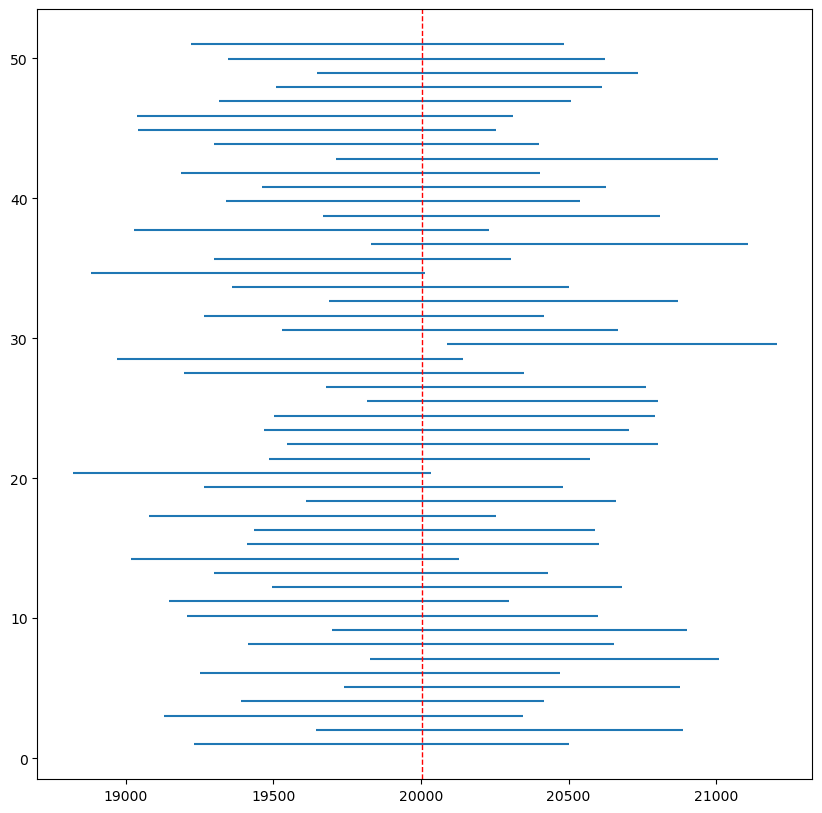

In [11]:
confidence_intervals = []
y = np.linspace(1,51) 
for i in range(50):
    sample = np.random.choice(population, size=100, replace=True)
    sample_mean = sample.mean()
    s = np.std(sample, ddof=1) 
    SE = s / np.sqrt(len(sample))
    ME = z_critical * SE 
    lower_bound = sample_mean - ME 
    upper_bound = sample_mean + ME 
    confidence_intervals.append((lower_bound, upper_bound))
possibile_mean_min=min(min(bound) for bound in confidence_intervals)
possibile_mean_max=max(max(bound) for bound in confidence_intervals)    

fig, ax = plt.subplots(figsize=(10,10))
for i in range(50):
    lower, upper = confidence_intervals[i]
    ax.hlines(y[i], xmin=lower,xmax=upper)
ax.axvline(population_mean, linestyle='--', linewidth=1, color = 'r')
plt.show()

In [12]:
print("94.1 percentage of my 1000 intervals contained population mean.")
print("If we repeatedly take samples and construct confidence intervals using this method approximately 95% those intervals will contains the population mean.")
print("SE decreased by 2x because n is in denominator in SE = s / sqrt(n) ")
print("Width of confidence intervals will become narrower because margin of error will be decreased.")
print("Narrow confidence interval is more precise because it gives smaller range of plausible values for the unknown population mean.")

94.1 percentage of my 1000 intervals contained population mean.
If we repeatedly take samples and construct confidence intervals using this method approximately 95% those intervals will contains the population mean.
SE decreased by 2x because n is in denominator in SE = s / sqrt(n) 
Width of confidence intervals will become narrower because margin of error will be decreased.
Narrow confidence interval is more precise because it gives smaller range of plausible values for the unknown population mean.


---

# Task 6 — Confidence Level vs. Interval Width 
We should first explore what changes when we use:

90%,95%,99%

Use the same population setup as:

import numpy as np

np.random.seed(42)

population = np.random.normal(
    loc=20_000,
    scale=3_000,
    size=100_000
)

Take one random sample of 100 observations.

For this task, use the sample standard deviation s to estimate the standard error: SE = s / sqrt(n)

We will compare three confidence levels using these approximate critical values:

90%
95%
99%

### Part A — Basic sample statistics

Calculate:

1. sample mean xˉ
2. sample standard deviation s
3. sample size n
4. standard error SE

### Part B — Build three confidence intervals
For each confidence level, calculate:

ME=z∗×SE

and : 
CI = xˉ±ME

Calculate:

- 90% CI
- 95% CI
- 99% CI

### Part C — Calculate interval width
For each interval:

Width=Upper−Lower

Calculate:

- width of 90% CI
- width of 95% CI
- width of 99% CI

Then compare them.

Which is:

- narrowest?
- widest?

### Part D — Reasoning

Answer in your own words:

1. Why does the 99% confidence interval have to be wider than the 95% interval?
2. Why is the 90% confidence interval narrower?
3. Does increasing the confidence level change the sample mean?
4. Does increasing the confidence level change the standard error?
5. What actually changes when we go from 90% to 95% to 99%?

Think specifically about: z_critical

### Part E — Precision vs confidence

Suppose two analysts use the same sample.

Analyst A reports:

90% CI

Analyst B reports:

99% CI

Answer:

1. Which analyst gives the more precise estimate?
2. Which analyst gives the more confident interval?
3. Why is there a trade-off between precision and confidence?

### Part F — Sample size effect

Now keep the confidence level fixed at 95%.

Compare:

n=100

with:

n=400

You don't need to generate a new population. Just reason from:

SE=s/sqrt(n)

Answer:

1. If n increases from 100 to 400, by what factor does sqrt(n) change?
2. Approximately what happens to SE?
3. Approximately what happens to the margin of error?
4. Approximately what happens to the CI width?
5. Does a larger sample make the estimate more precise or less precise? 

In [13]:
np.random.seed(42)
import scipy.stats as st 

population = np.random.normal(
    loc=20000,
    scale=3000,
    size=100000,
)
n=100
sample = np.random.choice(population, size=n, replace=False)
sample_mean = sample.mean()
s = np.std(sample, ddof=1) 
SE = s / np.sqrt(n)

confidence = 0.90
alpha = 1-confidence
z_90 = st.norm.ppf(1-alpha/2) 
confidence = 0.95
alpha = 1-confidence
z_95 = st.norm.ppf(1-alpha/2) 
confidence = 0.99
alpha = 1-confidence
z_99 = st.norm.ppf(1-alpha/2) 

z_criticals = [z_90, z_95, z_99]
ci = []
for z in z_criticals:
    ME = z * SE 
    lower = sample_mean - ME 
    upper = sample_mean + ME 
    ci.append((lower,upper)) 



print(f'Standard Erro is {SE}')
print(f"ci_90 = {ci[0]}")
print(f"ci_95 = {ci[1]}")
print(f"ci_99 = {ci[2]}")

Standard Erro is 315.5319210099291
ci_90 = (np.float64(19446.5034074802), np.float64(20484.511056864492))
ci_95 = (np.float64(19347.076031020148), np.float64(20583.938433324543))
ci_99 = (np.float64(19152.750863829893), np.float64(20778.263600514798))


In [14]:
widths = [bound[1]-bound[0] for bound in ci]
print(f"CI_90's width is {widths[0]}")
print(f"CI_95's width is {widths[1]}")
print(f"CI_99's width is {widths[2]}")

print(f"The narrowest is of CI_90 ({widths[0]})")
print(f"The widest is of CI_99 ({widths[2]})")
print(f"As the confidence level increases, the critical z-value increases. Since the margin of error is z_critical * SE, the \
margin of error increases, which makes the confidence interval wider.")

CI_90's width is 1038.0076493842935
CI_95's width is 1236.8624023043958
CI_99's width is 1625.5127366849047
The narrowest is of CI_90 (1038.0076493842935)
The widest is of CI_99 (1625.5127366849047)
As the confidence level increases, the critical z-value increases. Since the margin of error is z_critical * SE, the margin of error increases, which makes the confidence interval wider.


In [15]:
print("Increasing the confidence level does not affect sample mean.")
print("Confidence level has not impact on standard error.")
print("Between confidence intervals what is changed is the critical z-values, therefore margin of erros and confidence width, because confidence interval bounds are changed.")
print("Because in the wider interval has greater chance, across repeated sampling, of containing the true population mean.")

Increasing the confidence level does not affect sample mean.
Confidence level has not impact on standard error.
Between confidence intervals what is changed is the critical z-values, therefore margin of erros and confidence width, because confidence interval bounds are changed.
Because in the wider interval has greater chance, across repeated sampling, of containing the true population mean.


In [16]:
print("Analyst A is give more precise estiamte because confidence interval is narrower.")
print("Analyst A has higher confidence level")
print("Narrower interval gives us a smaller range for plausible values for population mean.")
print("more confidence => less precision, more precision => less confidence.")

Analyst A is give more precise estiamte because confidence interval is narrower.
Analyst A has higher confidence level
Narrower interval gives us a smaller range for plausible values for population mean.
more confidence => less precision, more precision => less confidence.


In [17]:
print(10)
print(20)
print("by factor 2")
print("Standard error is decreased by factor 2")
print("Margin of error as well is decreased.")
print("Confidence interval width also is decreases as consequence of decreased ME.")
print("With increasing the sample size we increase the precision of our estimate because we decreased CI width.")

10
20
by factor 2
Standard error is decreased by factor 2
Margin of error as well is decreased.
Confidence interval width also is decreases as consequence of decreased ME.
With increasing the sample size we increase the precision of our estimate because we decreased CI width.


---

# Task 7 — Hypothesis Testing Intuition

A hotel claims its average daily revenue is:

μ0=20,000

You take a random sample of:

n=100

and obtain:  xˉ=20,650

Assume: σ=3000

### Part A

Write the hypotheses:

H0:

H1:

We want to test whether the true mean is different from £20,000.

Then explain what each hypothesis means in words.


### Part B

Calculate:

SE=population_std_dev / sqrt(n)

Then calculate:

sample_mean - population_mean


Now answer:

Is the observed difference of £650 large or small compared with the standard error?

Do not calculate the z-score yet.

### Part C

Assume H0 is true.

Then the sampling distribution of the sample mean is centered at:

20,000

with standard error: 3000/sqrt(100)

Answer:

1. Around what value should sample means fluctuate?
2. What is the standard error?
3. Does a sample mean of £20,650 look ordinary or somewhat unusual?

### Part D — Significance level

Now use:

α=0.05

Explain in your own words what α=0.05 means in hypothesis testing.

Important: do not say:

“There is a 5% probability that H0 is true.”

That is not what α means.

### Next part

Our observed difference was:

650

and:

SE=300

Calculate:

z=xˉ−μ0/ SE

Then answer:

1. What is the z-score?
2. What does that z-score mean in words?
3. Is it outside the critical region [−1.96,1.96]?
4. Based on that, would you reject H0 or fail to reject H0?

In [18]:
print("H0: The true mean is £20_000.") # true mean is exactly 20 000
print("H1: The true mean is NOT  £20_000.") # true mean is everything but not 20 000

H0: The true mean is £20_000.
H1: The true mean is NOT  £20_000.


In [19]:
sigma = 3000 # population_std_dev
n = 100 # size of sample 
SE = sigma / np.sqrt(n) 
sample_mean = 20650
m0 = 20000
print(f"Standard Error is {SE}")
print(f"Observed difference is {sample_mean - m0}")
print(f"Observed difference is bigger than Standard error.")
print("That already suggests the sample mean is not extremely close to what we would typically expect if H0 were true.")

Standard Error is 300.0
Observed difference is 650
Observed difference is bigger than Standard error.
That already suggests the sample mean is not extremely close to what we would typically expect if H0 were true.


In [20]:
print("Around 20000")
print("Standard error measures how much sample means typically vary around the true population mean when we repeatedly take samples of the same size.")
print("20650 looks somewhat unusual, because is more 2std errors above the population mean(20000).")

Around 20000
Standard error measures how much sample means typically vary around the true population mean when we repeatedly take samples of the same size.
20650 looks somewhat unusual, because is more 2std errors above the population mean(20000).


In [21]:
print("Alpha = 5% means we accept a 5% risk to rejecting H0 even though H0 is actually true.This is a Type I error or false positive test.")
print("Aplha = P(reject HO | HO is true)")
alpha = 0.05
z = (sample_mean - m0)/SE 
z_critical = st.norm.ppf(1-alpha/2) # because it is two tail test, we test if m0 is exactly 20000.
print(f'The sample mean of 20 650 is approximately {z} standard errors above the hypothesised population mean 20000.')
print(f"It is {"inside " if (z>z_critical or z<-z_critical) else "outside"} the critical region")
print("I would reject H0, because it is inside in critical region.")

Alpha = 5% means we accept a 5% risk to rejecting H0 even though H0 is actually true.This is a Type I error or false positive test.
Aplha = P(reject HO | HO is true)
The sample mean of 20 650 is approximately 2.1666666666666665 standard errors above the hypothesised population mean 20000.
It is inside  the critical region
I would reject H0, because it is inside in critical region.


# p_values

# Task 8 — Calculate and interpret the p-value
Using SciPy, calculate the two-sided p-value from your z-score.

For a positive z, first find the probability in the right tail:

right_tail = ...

Then remember that this is a two-sided test, so there are two extreme tails.

Calculate: p_value = ...

Then answer in your own words:

1. What numerical p-value did you get?
2. What does that p-value mean assuming H0 is true?
3. Compare it with: α=0.05
4. Should you reject H0 or fail to reject H0 ?
5. Does rejecting H0 prove that the true mean is exactly £20,650? Why or why not?

In [22]:
import scipy.stats as st 
alpha=0.05
right_tail = 1 - st.norm.cdf(z)
p_value = 2 * (1-st.norm.cdf(abs(z)))
print(f"Right tail is {right_tail}")
print(f"p value is {np.abs(p_value)}")
print(f"p_value is lower than significance level. {p_value} < {alpha}")
print("There is significance evidence to reject H0, because p_value is less than alpha.")
print("Rejecting H0 does NOT prove that true mean is exactly 20650, £20,650 is only the sample mean; the actual population mean is unknown.")

Right tail is 0.015130140010235826
p value is 0.030260280020471653
p_value is lower than significance level. 0.030260280020471653 < 0.05
There is significance evidence to reject H0, because p_value is less than alpha.
Rejecting H0 does NOT prove that true mean is exactly 20650, £20,650 is only the sample mean; the actual population mean is unknown.


---

# Task 9 — One-sided vs Two-sided Hypothesis Tests
Use this hotel revenue scenario:
m0=20000

sample_mean = 20650

sigma = 3000

n = 100

SE = sigmna / np.sqrt(n)

z = (sample_mean - m0)/SE


### Part A — Three possible alternatives

Write the hypotheses for these three cases:

Case 1 — Two-sided

We want to test whether revenue is simply different from £20,000.

H0:
H1:

Case 2 — Right-sided

We want to test whether revenue is greater than £20,000.

H0:
H1:

Case 3 — Left-sided

We want to test whether revenue is less than £20,000.

H0:
H1:

###  Part B — Calculate the z-score
Then interpret it in words:

The sample mean is ___ standard errors above/below the hypothesized population mean.

### Part C — Calculate three p-values

Using the same observed z, calculate:

Two-sided:
p_two = ...

Right-sided: p_right= ...
Left-sided: p_left=....

Hints:

P(Z>z)=1−CDF(z)
P(Z<z)=CDF(z)

For the two-sided case, use both tails.

### Part D — Compare with α=0.05

For each test, decide:

reject H0

or fail to reject H0

Create something like:

Two-sided: ...
Right-sided: ...
Left-sided: ...

### Part E — Reasoning

Answer in your own words:

1. Why is the right-sided p-value smaller than the two-sided p-value here?
2. Why is the left-sided p-value very large?
3. If your research question was specifically:

“Has average hotel revenue increased?”

which alternative hypothesis should you use?

4. Why should you decide whether the test is one-sided or two-sided before looking at the sample result?

In [23]:
m0=20000
sample_mean = 20650
sigma = 3000
n = 100

SE = sigma / np.sqrt(n)

print("Two sided: H0 - revenue is equal to 20 000. H1: Revenue is different from 20 000,")
print("Right-sided: H0 - Revenue is smaller or eqault to 20 000. H1 - Revenue is more than 20 000.")
print("Left-sided: H0 - Revenue is 20000 or greater. H1 - Revenue is less than 20 000")

z = (sample_mean - m0) / SE 
print(f"z = {z}")
alpha = 0.05 
p_two = 2 * (1 - st.norm.cdf(abs(z)))
print(f"p_two = {p_two}")
p_right = 1 - st.norm.cdf(z)
print(f"p_right = {p_right}")
p_left = st.norm.cdf(z)
print(f"p_left = {p_left}")

print(f"Two-sided: p_two < alpha {p_two} < {alpha}, significance evidence to reject H0.")
print(f"Right-sided: p_right < alpha {p_right} < {alpha}, significance evidence to reject H0.")
print(f"Left-sided: p_left > alpha {p_left} > {alpha}, insulfficient evidence to reject H0.")

print("Because we accept extremes can be only in right tail.")
print("Because we took the cumulative density proabability left to the z value.")
print("H1: Hotel revenue has increased.")
print("two sided is choosen when we care about difference in either direction.m0 != 20k. Right sided, specifically care about increase H1: m0 > 20k\
LEft-sided: speciffically care about decrease. m0<20k.")
print("We choose the direction of the test before looking at the sample because it should be determined by the research question,\
not wichever direction the observed data happened to move.")


Two sided: H0 - revenue is equal to 20 000. H1: Revenue is different from 20 000,
Right-sided: H0 - Revenue is smaller or eqault to 20 000. H1 - Revenue is more than 20 000.
Left-sided: H0 - Revenue is 20000 or greater. H1 - Revenue is less than 20 000
z = 2.1666666666666665
p_two = 0.030260280020471653
p_right = 0.015130140010235826
p_left = 0.9848698599897642
Two-sided: p_two < alpha 0.030260280020471653 < 0.05, significance evidence to reject H0.
Right-sided: p_right < alpha 0.015130140010235826 < 0.05, significance evidence to reject H0.
Left-sided: p_left > alpha 0.9848698599897642 > 0.05, insulfficient evidence to reject H0.
Because we accept extremes can be only in right tail.
Because we took the cumulative density proabability left to the z value.
H1: Hotel revenue has increased.
two sided is choosen when we care about difference in either direction.m0 != 20k. Right sided, specifically care about increase H1: m0 > 20kLEft-sided: speciffically care about decrease. m0<20k.
We cho

---

# Type I Error, Type II Error, and Power
Use this scenario:

A hotel chain currently claims:

m0=20,000

ou want to test whether a new pricing strategy increases average daily revenue.

So:

H0:μ≤20,000

H1:μ>20,000

Use:

α=0.05

Do this conceptually first. No SciPy yet.

### Part A — Type I Error

Suppose the true mean is actually:

μ=20,000

but your test rejects H0

Answer:

1. What wrong conclusion did you make?
2. Is this a Type I or Type II error?
3. How is this error connected to α=0.05?

### Part B — Type II Error

Now suppose the true mean is actually:

μ=20,800

but your test fails to reject H0.

Answer:

1. What wrong conclusion did you make?
2. Is this Type I or Type II error?
3. Why can this happen even if the true mean really is above £20,000?

### Part C — Decision table

Complete this table:

| Reality    | Reject (H_0) | Fail to reject (H_0) |
| ---------- | ------------ | -------------------- |
| (H_0) true | ?            | ?                    |
| (H_1) true | ?            | ?                    |

Use these labels:

Correct decision
- Type I error
- Type II error

### Part D — Power

Power is:

P(reject H0∣H1 is true)

Answer in your own words:

1. What does high statistical power mean?
2. If power is 0.90, what does that mean?
3. What is the relationship between power and Type II error probability β?

Hint:

Power=1−β

### Part E — What affects power?

Without calculating anything yet, predict whether each change would usually make power increase or decrease:

1. Increase sample size n
2. Increase population standard deviation σ
3. Increase the true difference between μ and μ0
4. Increase α from 0.05 to 0.10

For each one, write increase/decrease and one short reason.

In [25]:
#A 
m0=20000
print('H0: New pricing strategy does not increase average daily revenue m0 <= 20 000.')
print('H1: New pricing stragegy has increased average daily revenue, m0 > 20 000.')

print("False positive.(Type I Error.) Reject H0 even though is true.")
print("With increasing alpha, it makes rejection region larger by moving the critical boundary torward to the center.")
#B
print("We failed to reject the H0, our conclusion is new strategy is not working.")
print("This is false negative. Fail to reject H0 even thought H0 is false. Type II Error.")
print("Even if the true mean is 20800, random sampling may produce a sample mean close enough to 20 000 that we do not get sufficient evidence to reject H0.")
#C 
print(
''' 
| Reality       | Reject (H_0)            | Fail to reject (H_0) |
| ------------- | ------------            | -------------------- |
| (H_0) is true | Type I error            | Correct decision     |
| (H_1) is true | Correct decision        | Type II error        |
'''
)
# D 
print("Statistical power represent the probability correct to reject a false null hypothesis.")
print("If power is 0.90, it means that there is 10 % for type II error.")
print("Power increases and Type II error decreases.")
# E 
print("Increasing n, increasing power.")
print("increasing population std deviation, decrease power.")
print("increasing true difference between m0 and m, increase.")
print("increaing alpha, increasing power.")

H0: New pricing strategy does not increase average daily revenue m0 <= 20 000.
H1: New pricing stragegy has increased average daily revenue, m0 > 20 000.
False positive.(Type I Error.) Reject H0 even though is true.
With increasing alpha, it makes rejection region larger by moving the critical boundary torward to the center.
We failed to reject the H0, our conclusion is new strategy is not working.
This is false negative. Fail to reject H0 even thought H0 is false. Type II Error.
Even if the true mean is 20800, random sampling may produce a sample mean close enough to 20 000 that we do not get sufficient evidence to reject H0.
 
| Reality       | Reject (H_0)            | Fail to reject (H_0) |
| ------------- | ------------            | -------------------- |
| (H_0) is true | Type I error            | Correct decision     |
| (H_1) is true | Correct decision        | Type II error        |

Statistical power represent the probability correct to reject a false null hypothesis.
If powe

# Next task — Calculate β and statistical power
Use the same hotel scenario:
H0:μ≤20,000
H:μ>20,000

Given:

α=0.05
σ=2000
n=100

For this right-tailed z-test, use:

zcrit=1.645


### Part A — Find the critical sample mean

First calculate the standard error:

SE=sigma / sqrt(n)

Then calculate:

xˉcrit=μ0+zcrit⋅SE

This is the sample-mean boundary above which we reject H0

Now suppose the true mean is actually:

μ1=20,800

### Part B — Find β

A Type II error happens when the true mean is 20,800, but the sample mean does not cross the critical boundary.

So calculate the z-score of the critical boundary relative to the distribution centered at 20,800:

zβ= x crit -m1 /SE

Then use the standard normal table or a normal-CDF function if you already know one to find:

β=P(Z≤zβ)

### Part C — Find power

Power=1−β

Your task

Calculate and report:

1. SE
2. x crit
3. z (beta)
4. beta
5. Power
6. Explain in words what your power result means in this hotel scenario.

Do the calculations yourself first.

In [38]:
alpha = 0.05
sigma = 2000
n = 100
z_critical = 1.645

SE = sigma / np.sqrt(n)
m0=20000
x_crit = m0 + z_critical * SE 
x_crit

z_beta = (x_crit - 20800) / SE 
beta = st.norm.cdf(z_beta)
power = 1 - beta
power
#power means probability to correct reject a false null hypothesis.
# Larger sample size reduces standard error, which makes real differences easier to detect, so statistical power increases.

np.float64(0.9907386471516638)

### Next should be power comparison across different sample sizes and effect sizes.
Next task — Compare power

Keep:

H0:μ≤20000

H1:μ>20000

Use:

α=0.05,σ=2000

| Scenario | (n) | True mean (\mu_1) |
| -------- | --: | ----------------: |
| A        |  25 |             20400 |
| B        | 100 |             20400 |
| C        | 100 |             20800 |
| D        | 400 |             20800 |

For each scenario calculate:

1. SE
2. Critical sample mean
3. zβ
4. β
5. Power

Then rank the scenarios from lowest power to highest power and explain why.

In [62]:
alpha = 0.05
sigma = 2000
z_critical = 1.645
sizes = [25,100,100,400]
m1 = [20400, 20400, 20800, 20800]
results = {}

for idx in range(len(sizes)):
    SE = sigma/ np.sqrt(sizes[idx])
    x_crit = 20000 + z_critical * SE 
    z_beta = (x_crit - m1[idx]) / SE 
    beta = st.norm.cdf(z_beta) 
    power = 1 - beta 
    results[chr(65+idx)] = power 
    
dict(sorted(results.items(), key=lambda x: x[1], reverse=True) )

{'D': np.float64(0.9999999998957867),
 'C': np.float64(0.9907386471516638),
 'B': np.float64(0.6387052043836872),
 'A': np.float64(0.2594635928547797)}

# Next task — Type I / Type II / Power mixed interpretation

Use this setup:

H0:μ≤50
H1:μ>50

A test is designed with:

α=0.05

and has:

Power=0.80

when the true mean is:

μ=55

Answer conceptually:

1. What is β?
2. If the true mean is really 55, what is the probability that the test fails to reject H0?
3. If H0 is actually true, what is the probability that the test incorrectly rejects it?
4. Which error is a false positive?
5. Which error is a false negative?
6. Suppose we increase sample size while keeping everything else fixed. What usually happens to:
- β
- power
- α

For 6, pay attention: increasing sample size does not automatically change every quantity.

In [63]:
alpha = 0.05 
power =0.80 
mu = 55 

# beta is probability for type II error. (Fail to reject H0 when it is actually false. false negative.)
# beta = 0.20
# 5%. 
# TYpe I error 
# Type II error 
# we decrease beta, therefore power is increased, alpha is kept, 

---

# First t-test exercise
First t-test exercise

A hotel claims its average customer spending is:

μ0=£100

You take a random sample of:

n=25

customers and find:

xˉ=£108

s=20

alpha = 0.05

### Part A — Hypotheses

Write:

H0

and

H1

Decide whether this is:

- left-tailed
- right-tailed
- two-tailed

### Part B — Standard error

Calculate:

SE=s / sqrt(n)

### Part C — t-statistic

Calculate:

t = (x - m0) / SE 

### Part D — Degrees of freedom

Calculate:

df=n−1



In [76]:
m0 = 100 
n = 25 
sample_mean = 108 
s = 20 
# H0: m0 <= 100 
# H1: m0 > 100 
# I would use right tailed test, because we want to test whether true mean is graeter than 100.

SE = s / np.sqrt(n)
t = (sample_mean - m0) / SE 
df = n - 1 
print(f'T-distribution = {t}')
print(f'Degree of freedon is {df}')
alpha = 0.05 
t_critical = st.t.ppf(1-alpha, df)
print(f"Critical t value is {t_critical}<{t} t which means we have significant evidence to reject H0.")

p_value = 1 - st.t.cdf(t,df)
print(f"p value is {p_value}, which is less than alpha {ap")

T-distribution = 2.0
Degree of freedon is 24
Critical t value is 1.710882079909428<2.0 t which means we have significant evidence to reject H0.


np.float64(0.028469924968295812)